In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

# Paths (updated and correct)
BASE_DIR = Path("/mnt/c/Users/AbdulHafeez/Brain_Tumor/dataset_split")

train_dir = BASE_DIR / "train"
val_dir   = BASE_DIR / "val"
test_dir  = BASE_DIR / "test"

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize
    rotation_range=15,       
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation & Test generators (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

# Load validation data
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

# Load test data (shuffle must be FALSE)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


2025-12-14 08:32:08.219155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 08:32:08.263848: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 08:32:10.538113: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 7390 images belonging to 4 classes.
Found 1582 images belonging to 4 classes.
Found 1588 images belonging to 4 classes.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = 4


model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Reduce feature maps instead of flattening
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()


I0000 00:00:1765701131.269337  105219 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,236 (1.74 MB)

 Trainable params: 455,236 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [4]:
model.optimizer


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_path = "best_cnn_model.keras"

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True
    )
]


In [6]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)


/home/abdulhafeez/miniconda3/envs/tf/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


2025-12-14 08:32:28.268841: I external/local_xla/xla/service/service.cc:163] XLA service 0x767510015530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-14 08:32:28.268885: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2025-12-14 08:32:28.324180: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-14 08:32:28.600438: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2025-12-14 08:32:28.714233: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-14 08:32:

  2/231 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.3594 - loss: 1.3797 

I0000 00:00:1765701157.300293  105391 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


231/231 ━━━━━━━━━━━━━━━━━━━━ 83s 316ms/step - accuracy: 0.3783 - loss: 1.3355 - val_accuracy: 0.5601 - val_loss: 1.0843
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 65s 282ms/step - accuracy: 0.5526 - loss: 1.0483 - val_accuracy: 0.5518 - val_loss: 0.9999
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 67s 287ms/step - accuracy: 0.6040 - loss: 0.9354 - val_accuracy: 0.5752 - val_loss: 1.0039
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 63s 273ms/step - accuracy: 0.6189 - loss: 0.8819 - val_accuracy: 0.6460 - val_loss: 0.8686
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 60s 260ms/step - accuracy: 0.6487 - loss: 0.8547 - val_accuracy: 0.6466 - val_loss: 0.8806
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 62s 266ms/step - accuracy: 0.6600 - loss: 0.8188 - val_accuracy: 0.6694 - val_loss: 0.8352
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 61s 265ms/step - accuracy: 0.6512 - loss: 0.8292 - val_accuracy: 0.6479 - val_loss: 0.8797
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 59s 255ms/step - accuracy: 0.6713 - loss: 0.7924 - val

In [7]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - accuracy: 0.6695 - loss: 0.7449
Test Accuracy: 0.6801
Test Loss: 0.7367


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step


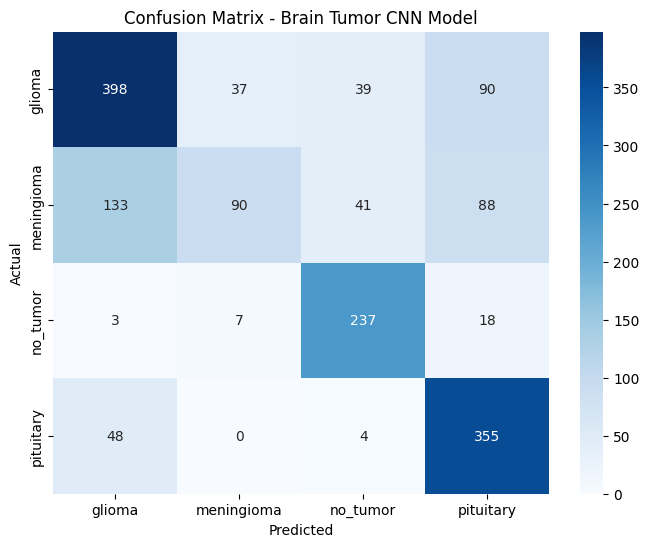


Classification Report:

              precision    recall  f1-score   support

      glioma       0.68      0.71      0.69       564
  meningioma       0.67      0.26      0.37       352
    no_tumor       0.74      0.89      0.81       265
   pituitary       0.64      0.87      0.74       407

    accuracy                           0.68      1588
   macro avg       0.68      0.68      0.65      1588
weighted avg       0.68      0.68      0.65      1588



In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test data
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_gen.classes

# Class names
labels = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Brain Tumor CNN Model")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=labels))


In [9]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


In [10]:
class_labels = list(train_gen.class_indices.keys())
print("Class Labels:", class_labels)


Class Labels: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [11]:
def predict_image(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Convert to array
    img_array = image.img_to_array(img)
    
    # Normalize (same as train_gen rescale=1/255)
    img_array = img_array / 255.0
    
    # Expand dims → model expects batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    predicted_label = class_labels[predicted_class]

    # Show image
    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Prediction: {predicted_label}")
    plt.show()

    return predicted_label


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


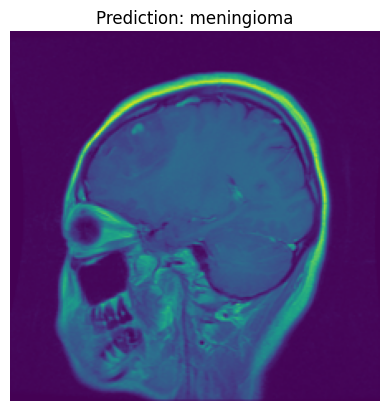

'meningioma'

In [30]:
predict_image(r"C:\Users\AbdulHafeez\Brain_Tumor\dataset_split\test\glioma\glioma8.png")


In [3]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[]

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

print(tf .__version__)

2025-12-14 08:20:52.495267: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 08:20:52.539905: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 08:20:54.369418: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
2.20.0


In [7]:
print(train_dir.exists(), val_dir.exists(), test_dir.exists())


True True True
